## Imports

In [1]:
import sys
import torch
from torch import nn
from pathlib import Path

top_dir = Path.cwd().parent
sys.path.insert(0, str(top_dir.absolute()))

from src import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

torch.Size([5, 5])
tensor([[0.+0.3242j, 0.+0.0000j, 0.+0.0000j, 0.+0.0000j, 0.+0.0000j],
        [-0.-0.8676j, -0.-0.1994j, 0.+0.0000j, 0.+0.0000j, 0.+0.0000j],
        [0.+0.4485j, -0.-0.2720j, -0.-0.1138j, 0.+0.0000j, 0.+0.0000j],
        [-0.-0.7353j, -0.-1.0357j, -0.-1.0671j, -0.-0.5375j, 0.+0.0000j],
        [0.+0.2394j, 0.+0.7184j, 0.+2.1365j, -0.-0.8132j, -0.-1.9612j]])
torch.Size([5])


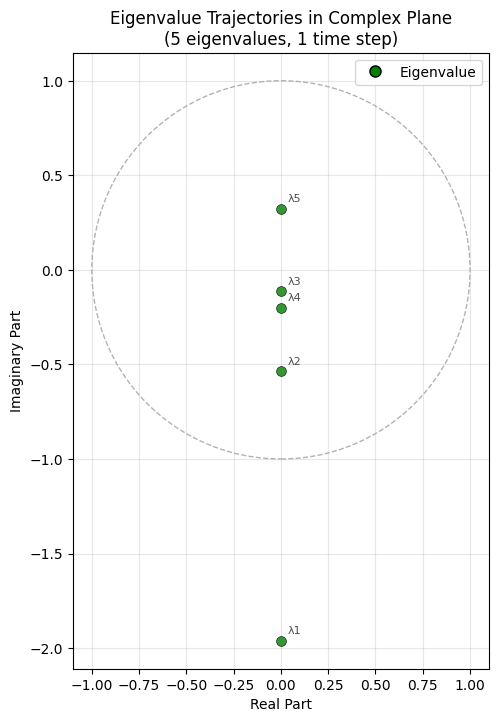

In [2]:
if 0:
    terms = torch.tensor([[-0.4003,  0.0847,  0.0664, -0.6702,  0.2006],
            [ 0.2372, -0.3414,  0.0847, -0.3909, -0.6381],
            [-0.1245,  0.4880,  0.0270, -0.5228,  0.5747],
            [-0.1167, -0.6507,  0.2438, -0.6049,  0.4791],
            [ 0.1488,  0.2158, -0.6491,  0.1951, -0.0678],
            [-0.1600,  0.2094, -0.6649, -0.5280, -0.6729]])
    terms = terms[1:,:]
else:
    size = 5
    tril_indices = torch.tril_indices(size, size)
    num_params = (size * (size + 1)) // 2  # Number of unique parameters
    params = torch.randn(num_params)

    terms = torch.zeros(size, size, device=params.device)
    terms[tril_indices[0], tril_indices[1]] = params
    symmetric_matrix = terms + terms.t() - torch.diag(terms.diag())

    terms = torch.tensor(1j) * terms
    terms = terms.to(torch.cfloat)

print(terms.shape)
print(terms)

eigvs = torch.linalg.eigvals(terms)
print(eigvs.shape)
plots.plot_eigvs([eigvs], save=False)

